<a href="https://colab.research.google.com/github/Kishor403658/RagaAI-Catalyst/blob/main/fLOWER_SPECIES_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install KaggleHub if not installed
!pip install kagglehub

import kagglehub
import os

# Change this to your Kaggle dataset
dataset_name = "alxmamaev/flowers-recognition"  # <-- replace with your dataset
path = kagglehub.dataset_download(dataset_name)

print("Dataset path:", path)


100%|██████████| 225M/225M [00:01<00:00, 164MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import os

# Image size (adjust if needed)
image_size = 128

# Transform images
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

# Dataset root folder
data_root = os.path.join(path, 'flowers')  # Point to the directory containing class subfolders

# Load the full dataset
full_dataset = torchvision.datasets.ImageFolder(
    root=data_root,
    transform=transform
)

# Define split ratios
train_size = int(0.8 * len(full_dataset)) # 80% for training
test_size = len(full_dataset) - train_size # Remaining for testing

# Split the dataset into training and testing sets
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Update class names for the split datasets (they share the same classes as the full_dataset)
# The `random_split` function returns `Subset` objects, which don't directly expose `classes`
# We can infer them from the original full_dataset
original_classes = full_dataset.classes
new_class_names = [cls.replace('-', '_') for cls in original_classes]  # simple rename

num_classes = len(new_class_names)
print("Classes:", new_class_names)
print("Number of classes:", num_classes)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [5]:
class GenericCNN(nn.Module):
    def __init__(self, num_classes):
        super(GenericCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self._to_linear = 128 * (image_size // 8) * (image_size // 8)

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model, loss, optimizer
model = GenericCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [6]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f} Accuracy: {accuracy:.2f}%")


Epoch [1/10] Loss: 148.6367 Accuracy: 39.27%
Epoch [2/10] Loss: 115.8370 Accuracy: 55.63%
Epoch [3/10] Loss: 102.8801 Accuracy: 62.24%
Epoch [4/10] Loss: 89.7768 Accuracy: 67.77%
Epoch [5/10] Loss: 79.9940 Accuracy: 71.50%
Epoch [6/10] Loss: 66.1239 Accuracy: 76.86%
Epoch [7/10] Loss: 53.3618 Accuracy: 81.78%
Epoch [8/10] Loss: 39.5938 Accuracy: 86.91%
Epoch [9/10] Loss: 31.3292 Accuracy: 90.21%
Epoch [10/10] Loss: 19.8384 Accuracy: 93.51%


In [7]:
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Loss: {test_loss:.4f} Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 35.9810 Test Accuracy: 68.29%


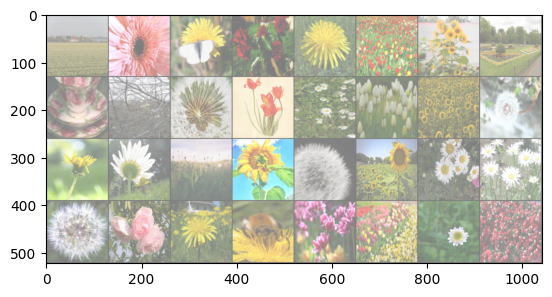

Predicted: ['dandelion', 'rose', 'dandelion', 'rose', 'dandelion', 'tulip', 'sunflower', 'sunflower', 'rose', 'sunflower', 'dandelion', 'tulip', 'daisy', 'daisy', 'sunflower', 'daisy', 'dandelion', 'daisy', 'dandelion', 'sunflower', 'dandelion', 'sunflower', 'daisy', 'sunflower', 'dandelion', 'rose', 'dandelion', 'sunflower', 'tulip', 'tulip', 'daisy', 'rose']
Actual:    ['tulip', 'rose', 'dandelion', 'rose', 'dandelion', 'tulip', 'sunflower', 'tulip', 'rose', 'daisy', 'dandelion', 'tulip', 'daisy', 'tulip', 'sunflower', 'dandelion', 'dandelion', 'daisy', 'dandelion', 'sunflower', 'dandelion', 'sunflower', 'daisy', 'daisy', 'dandelion', 'rose', 'dandelion', 'dandelion', 'tulip', 'tulip', 'daisy', 'rose']


In [8]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show images and predicted labels
imshow(torchvision.utils.make_grid(images.cpu()))
print("Predicted:", [new_class_names[p] for p in predicted.cpu()])
print("Actual:   ", [new_class_names[l] for l in labels.cpu()])

In [13]:
from PIL import Image
import torch
from torchvision import transforms

image_path = "/content/sunflower.jfif"  # replace with your image path

transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  # ensure 3 channels
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

img = Image.open(image_path)
input_tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension

model.eval()  # set model to evaluation mode
with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

print(f"Predicted flower species: {new_class_names[predicted.item()]}")

Predicted flower species: sunflower
